In [1]:
import os
import win32com.client as win32
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import clear_output
import pandas as pd
from sklearn.model_selection import ParameterSampler, ParameterGrid
import numpy as np

In [2]:
from models_FTS.components import parafins, olefins, others

In [3]:
kinetic_data = pd.read_pickle('kinetic_data_Hysys.pkl')

In [4]:
hysys = win32.Dispatch("HYSYS.Application")

In [5]:
os.chdir("Z:\\uem\\Doutorado\\Ensaios\\SAF\\SAF_8_08_08_2025\\SAF_kinetics_paper_code")
path = "hysys_simulation_optimization"
hy_path = os.path.abspath(path)

In [6]:
hy_case = hysys.Application.ActiveDocument
if hy_case == None:
    hy_case = hysys=SimulationCase.Open(hy_path)

hy_case.Visible = 1

In [7]:
hy_solver = hy_case.Solver
hy_int = hy_solver.Integrator

hy_f = hy_case.Flowsheet

hy_package = hy_f.FluidPackage

In [8]:
hy_ms = hy_f.MaterialStreams
hy_es = hy_f.EnergyStreams

In [9]:
hy_case.Solver.CanSolve = False

In [10]:
reactor = hy_case.Flowsheet.Operations.Item('PFR-100')

In [11]:
reactor.TotalVolume.GetValue('mL')

7.880000000000001

In [12]:
F1 = hy_ms.Item('F1')
F2 = hy_ms.Item('F2')
P0 = hy_ms.Item('P0')
H2 = hy_ms.Item('H2')
CO = hy_ms.Item('CO')
C1_C3 = hy_ms.Item('C1-C3')
C9_C15 = hy_ms.Item('C9-C15')
C16p = hy_ms.Item('C16p')
water = hy_ms.Item('water')

In [13]:
def solve_param_study(parametric_data):
    for i in parametric_data.index:
        T = parametric_data.T_C[i]
        P = parametric_data.P_bar[i]
        v_H2_in = parametric_data.v_H2_in[i]
        v_CO_in = parametric_data.v_CO_in[i]
                
        F1.Pressure.SetValue(P, 'bar')
        F2.Temperature.SetValue(T, 'C')
        CO.StdLiqVolFlow.SetValue(v_CO_in, "mL/min")
        H2.StdLiqVolFlow.SetValue(v_H2_in, "mL/min")

        # solve
        # 3. Ligar o solver
        hy_case.Solver.CanSolve = True
        print(f'running simulation {i} of {parametric_data.index.max()}')
        clear_output(wait = True)
        
        # 4. Aguardar a convergência
        while hy_case.Solver.IsSolving:
            pass
        
        hy_case.Solver.CanSolve = False
        
        P0_molar_flow = list(P0.ComponentMolarFlowValue)
        F2_molar_flow = list(F2.ComponentMolarFlowValue)
        
        F_H2_out = P0_molar_flow[P0.ComponentIndices('Hydrogen')[0]]
        F_CO_out = P0_molar_flow[P0.ComponentIndices('CO')[0]]
        
        F_H2_in = F2_molar_flow[F2.ComponentIndices('Hydrogen')[0]]
        F_CO_in = F2_molar_flow[F2.ComponentIndices('CO')[0]]
        
        parametric_data.loc[i, 'X_CO'] = (F_CO_in - F_CO_out) / F_CO_in
        parametric_data.loc[i, 'X_H2'] = (F_H2_in - F_H2_out) / F_H2_in
        parametric_data.loc[i, 'F_H2_out'] = F_H2_out * 1000 # convert from kmol/s to mol/s
        parametric_data.loc[i, 'F_CO_out'] = F_CO_out * 1000
        parametric_data.loc[i, 'm_C1_C3'] = C1_C3.MassFlowValue
        parametric_data.loc[i, 'm_C9_C15'] = C9_C15.MassFlowValue
        parametric_data.loc[i, 'm_C16p'] = C16p.MassFlowValue
        parametric_data.loc[i, 'm_water'] = water.MassFlowValue

    return parametric_data

In [14]:
H2_CO_in = np.arange(1.5, 2.75, 0.25)
v_H2_in = 180 * (H2_CO_in / ( 1 + H2_CO_in ))

param_grid = {'T_C'      : np.arange(210, 300, 10), 
              'P_bar'     : np.arange(15, 30, 5),
              'v_H2_in'    : v_H2_in,
              'v_CO_in' : [0],
             }

parametric_data = pd.DataFrame(ParameterGrid(param_grid))
parametric_data.v_CO_in = 180 - parametric_data.v_H2_in
parametric_data = solve_param_study(parametric_data)

parametric_data['C9_C15_sel'] = parametric_data.m_C9_C15/(
    parametric_data[['m_C1_C3', 'm_C16p']].sum(axis = 'columns')
)
parametric_data['H2_CO'] = parametric_data.v_H2_in / parametric_data.v_CO_in
parametric_data.to_pickle('parametric_data/data_lowP.pkl')

running simulation 134 of 134


In [15]:
parametric_data = pd.read_pickle('parametric_data/data_lowP.pkl')

In [16]:
parametric_data[[r'$\mathrm{\dot{m}_{C1-C3}}$ (g/d)', 
                 r'$\mathrm{\dot{m}_{C9-C15}}$ (g/d)', 
                 r'$\mathrm{\dot{m}_{C16+}}$ (g/d)', 
                 r'$\mathrm{\dot{m}_{H_2O}}$ (g/d)']] = parametric_data[['m_C1_C3', 
                                                                        'm_C9_C15', 
                                                                        'm_C16p', 
                                                                        'm_water']]*1000*60*60*24

In [17]:
parametric_data.to_excel('parametric_data/data_lowP.ods')

In [18]:
new_names_mapping = {
    'P_bar': 'P (bar)',
    'T_C': 'T (ºC)',
    'v_H2_in': r'$\mathrm{v_{H_2,in}}$ (mL/min)',
    'v_CO_in': r'$\mathrm{v_{CO,in}}$ (mL/min)',
    'H2_CO': r'$\mathrm{H_2/CO}$',
    'X_CO': r'$\mathrm{X_{CO}}$',
    'X_H2': r'$\mathrm{X_{H_2}}$',
    'C9_C15_sel': r'$\mathrm{Sel_{C9-C15}}$',
}
parametric_data = parametric_data.rename(columns=new_names_mapping)

In [19]:
parametric_data.columns

Index(['P (bar)', 'T (ºC)', '$\mathrm{v_{CO,in}}$ (mL/min)',
       '$\mathrm{v_{H_2,in}}$ (mL/min)', '$\mathrm{X_{CO}}$',
       '$\mathrm{X_{H_2}}$', 'F_H2_out', 'F_CO_out', 'm_C1_C3', 'm_C9_C15',
       'm_C16p', 'm_water', '$\mathrm{Sel_{C9-C15}}$', '$\mathrm{H_2/CO}$',
       '$\mathrm{\dot{m}_{C1-C3}}$ (g/d)', '$\mathrm{\dot{m}_{C9-C15}}$ (g/d)',
       '$\mathrm{\dot{m}_{C16+}}$ (g/d)', '$\mathrm{\dot{m}_{H_2O}}$ (g/d)'],
      dtype='str')

In [20]:
plot_data = parametric_data.melt(
    id_vars = ['P (bar)', 'T (ºC)', r'$\mathrm{H_2/CO}$',
               r'$\mathrm{v_{CO,in}}$ (mL/min)', r'$\mathrm{v_{H_2,in}}$ (mL/min)']
    )

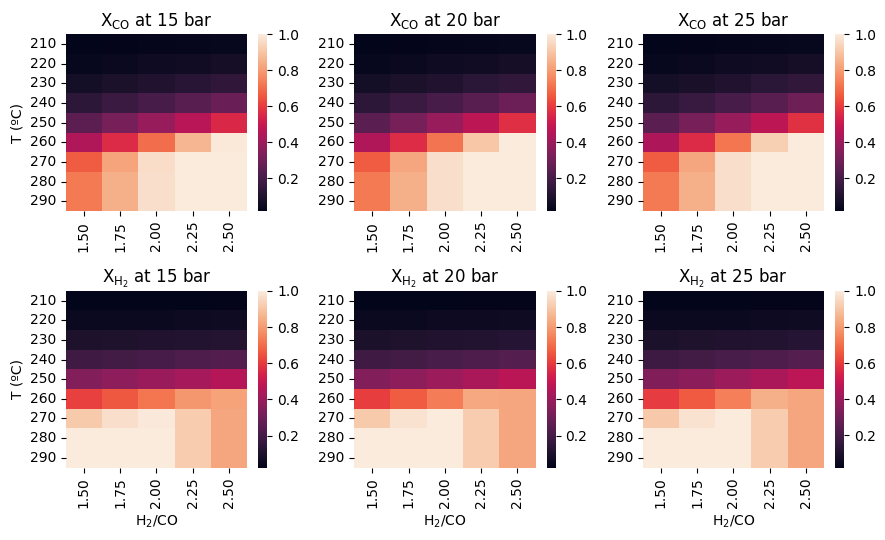

In [21]:
pressures = [15, 20, 25]
variables = [r'$\mathrm{X_{CO}}$', r'$\mathrm{X_{H_2}}$']
fig, ax = plt.subplots(2, 3, figsize=(9, 5.5)) # Slightly wider for clarity

for i, var in enumerate(variables):
    for j, p in enumerate(pressures):
        # 1. Filter and Pivot
        pivot_table = plot_data[
            (plot_data['P (bar)'] == p) & (plot_data['variable'] == var)
        ].pivot(index="T (ºC)", columns=r'$\mathrm{H_2/CO}$', values="value")
        
        # 2. Plot Heatmap (cbar_kws removed)
        sns.heatmap(data=pivot_table, ax=ax[i, j])
        
        # 3. Format tick labels
        ax[i, j].set_xticklabels(["{:.2f}".format(x) for x in pivot_table.columns])
        ax[i, j].set_yticklabels(["{:d}".format(int(y)) for y in pivot_table.index])
        
        # 4. Consolidate info into Title
        ax[i, j].set_title(f"{var} at {p} bar")
        
        # Optional: Clean up inner labels for a professional look
        if i != len(variables)-1: ax[i, j].set_xlabel('') # Remove X-label for top row
        if j > 0: ax[i, j].set_ylabel('')  # Remove Y-label for middle/right columns

plt.tight_layout()

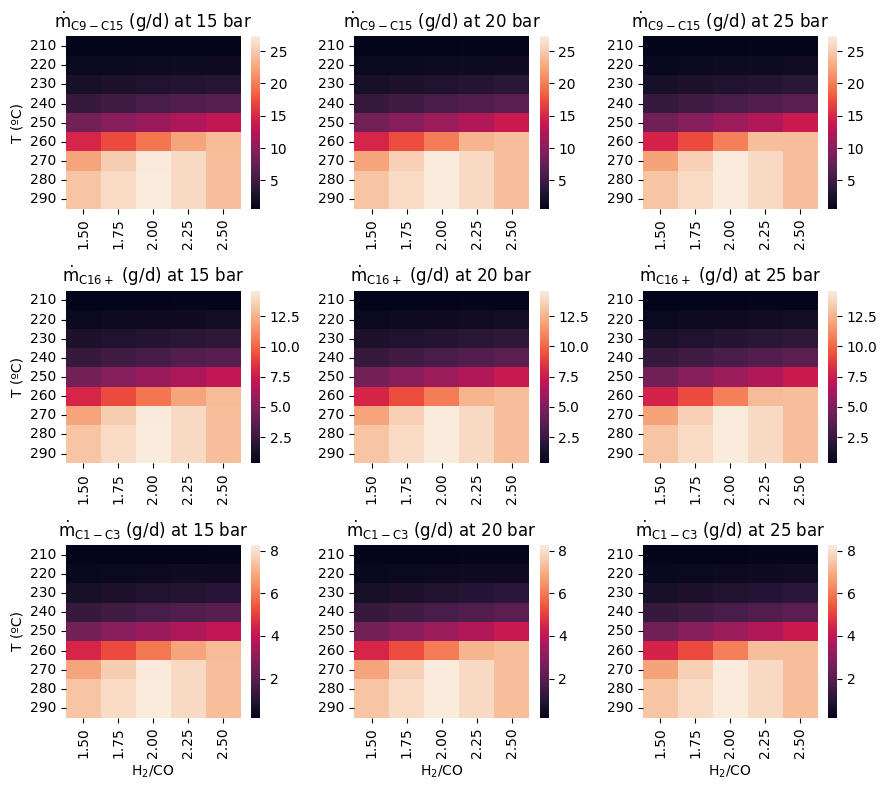

In [22]:
pressures = [15, 20, 25]
variables = [r'$\mathrm{\dot{m}_{C9-C15}}$ (g/d)', 
             r'$\mathrm{\dot{m}_{C16+}}$ (g/d)',
             r'$\mathrm{\dot{m}_{C1-C3}}$ (g/d)']
fig, ax = plt.subplots(3, 3, figsize=(9, 8)) # Slightly wider for clarity

for i, var in enumerate(variables):
    for j, p in enumerate(pressures):
        # 1. Filter and Pivot
        pivot_table = plot_data[
            (plot_data['P (bar)'] == p) & (plot_data['variable'] == var)
        ].pivot(index="T (ºC)", columns=r'$\mathrm{H_2/CO}$', values="value")
        
        # 2. Plot Heatmap (cbar_kws removed)
        sns.heatmap(data=pivot_table, ax=ax[i, j])
        
        # 3. Format tick labels
        ax[i, j].set_xticklabels(["{:.2f}".format(x) for x in pivot_table.columns])
        ax[i, j].set_yticklabels(["{:d}".format(int(y)) for y in pivot_table.index])
        
        # 4. Consolidate info into Title
        ax[i, j].set_title(f"{var} at {p} bar")

        # Optional: Clean up inner labels for a professional look
        if i != len(variables)-1: ax[i, j].set_xlabel('') # Remove X-label for top row
        if j > 0: ax[i, j].set_ylabel('')  # Remove Y-label for middle/right columns
plt.tight_layout()

fig_name = 'm_out_parametric_study.pdf'
plt.savefig('Z:\\uem\\Doutorado\\Papers\\SAF_kinetics\\figures\\'+fig_name, 
            bbox_inches = 'tight')

In [23]:
parametric_data.loc[parametric_data.m_C9_C15 == parametric_data.m_C9_C15.max()]

,P (bar),T (ºC),"$\mathrm{v_{CO,in}}$ (mL/min)","$\mathrm{v_{H_2,in}}$ (mL/min)",$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,F_H2_out,F_CO_out,m_C1_C3,m_C9_C15,m_C16p,m_water,$\mathrm{Sel_{C9-C15}}$,$\mathrm{H_2/CO}$,$\mathrm{\dot{m}_{C1-C3}}$ (g/d),$\mathrm{\dot{m}_{C9-C15}}$ (g/d),$\mathrm{\dot{m}_{C16+}}$ (g/d),$\mathrm{\dot{m}_{H_2O}}$ (g/d)
37,15,280,60.0,120.0,0.969017,1.0,3.438403e-13,0.000001,9.553365e-08,3.156843e-07,1.691087e-07,7.387371e-07,1.192872,2.0,8.254107,27.275128,14.61099,63.826884


In [24]:
parametric_data.loc[
    (parametric_data['P (bar)'] == 20) &
    (parametric_data['T (ºC)'] == 280) &
    (parametric_data['$\\mathrm{H_2/CO}$'] == 2)
]

,P (bar),T (ºC),"$\mathrm{v_{CO,in}}$ (mL/min)","$\mathrm{v_{H_2,in}}$ (mL/min)",$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,F_H2_out,F_CO_out,m_C1_C3,m_C9_C15,m_C16p,m_water,$\mathrm{Sel_{C9-C15}}$,$\mathrm{H_2/CO}$,$\mathrm{\dot{m}_{C1-C3}}$ (g/d),$\mathrm{\dot{m}_{C9-C15}}$ (g/d),$\mathrm{\dot{m}_{C16+}}$ (g/d),$\mathrm{\dot{m}_{H_2O}}$ (g/d)
82,20,280,60.0,120.0,0.969016,1.0,1.157409e-14,0.000001,9.553364e-08,3.156729e-07,1.691113e-07,7.387342e-07,1.192817,2.0,8.254107,27.274141,14.611215,63.826639


In [25]:
parametric_data.loc[parametric_data.m_C16p == parametric_data.m_C16p.max()]

,P (bar),T (ºC),"$\mathrm{v_{CO,in}}$ (mL/min)","$\mathrm{v_{H_2,in}}$ (mL/min)",$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,F_H2_out,F_CO_out,m_C1_C3,m_C9_C15,m_C16p,m_water,$\mathrm{Sel_{C9-C15}}$,$\mathrm{H_2/CO}$,$\mathrm{\dot{m}_{C1-C3}}$ (g/d),$\mathrm{\dot{m}_{C9-C15}}$ (g/d),$\mathrm{\dot{m}_{C16+}}$ (g/d),$\mathrm{\dot{m}_{H_2O}}$ (g/d)
127,25,280,60.0,120.0,0.969016,1.0,5.450647e-15,0.000001,9.553357e-08,3.156738e-07,1.691262e-07,7.387338e-07,1.192753,2.0,8.254101,27.274216,14.6125,63.826603


In [26]:
parametric_data.loc[parametric_data.m_C1_C3 == parametric_data.m_C1_C3.max()]

,P (bar),T (ºC),"$\mathrm{v_{CO,in}}$ (mL/min)","$\mathrm{v_{H_2,in}}$ (mL/min)",$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,F_H2_out,F_CO_out,m_C1_C3,m_C9_C15,m_C16p,m_water,$\mathrm{Sel_{C9-C15}}$,$\mathrm{H_2/CO}$,$\mathrm{\dot{m}_{C1-C3}}$ (g/d),$\mathrm{\dot{m}_{C9-C15}}$ (g/d),$\mathrm{\dot{m}_{C16+}}$ (g/d),$\mathrm{\dot{m}_{H_2O}}$ (g/d)
37,15,280,60.0,120.0,0.969017,1.0,3.438403e-13,0.000001,9.553365e-08,3.156843e-07,1.691087e-07,7.387371e-07,1.192872,2.0,8.254107,27.275128,14.61099,63.826884


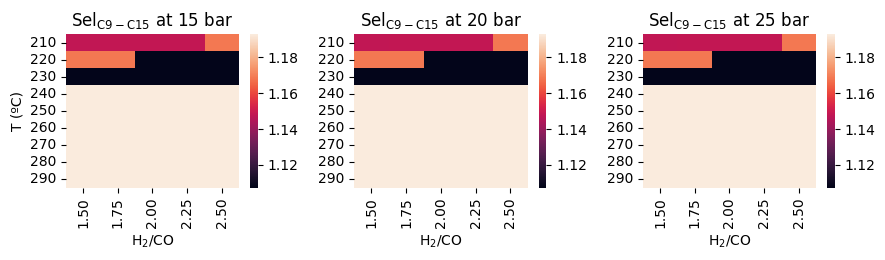

In [27]:
pressures = [15, 20, 25]
variables = [r'$\mathrm{Sel_{C9-C15}}$']
fig, ax = plt.subplots(1,3,figsize=(9, 2.7)) # Slightly wider for clarity

for i, var in enumerate(variables):
    for j, p in enumerate(pressures):
        # 1. Filter and Pivot
        pivot_table = plot_data[
            (plot_data['P (bar)'] == p) & (plot_data['variable'] == var)
        ].pivot(index="T (ºC)", columns=r'$\mathrm{H_2/CO}$', values="value")
        
        # 2. Plot Heatmap (cbar_kws removed)
        sns.heatmap(data=pivot_table, ax=ax[j])
        
        # 3. Format tick labels
        ax[j].set_xticklabels(["{:.2f}".format(x) for x in pivot_table.columns])
        ax[j].set_yticklabels(["{:d}".format(int(y)) for y in pivot_table.index])
        
        # 4. Consolidate info into Title
        ax[j].set_title(f"{var} at {p} bar")

        # Optional: Clean up inner labels for a professional look
        if i != len(variables)-1: ax[j].set_xlabel('') # Remove X-label for top row
        if j > 0: ax[j].set_ylabel('')  # Remove Y-label for middle/right columns
plt.tight_layout()
fig_name = 'Sel_C9_C15_parametric_study.pdf'
plt.savefig('Z:\\uem\\Doutorado\\Papers\\SAF_kinetics\\figures\\'+fig_name, 
            bbox_inches = 'tight')

In [28]:
parametric_data.loc[parametric_data[r'$\mathrm{Sel_{C9-C15}}$'] == parametric_data[r'$\mathrm{Sel_{C9-C15}}$'].max()]

,P (bar),T (ºC),"$\mathrm{v_{CO,in}}$ (mL/min)","$\mathrm{v_{H_2,in}}$ (mL/min)",$\mathrm{X_{CO}}$,$\mathrm{X_{H_2}}$,F_H2_out,F_CO_out,m_C1_C3,m_C9_C15,m_C16p,m_water,$\mathrm{Sel_{C9-C15}}$,$\mathrm{H_2/CO}$,$\mathrm{\dot{m}_{C1-C3}}$ (g/d),$\mathrm{\dot{m}_{C9-C15}}$ (g/d),$\mathrm{\dot{m}_{C16+}}$ (g/d),$\mathrm{\dot{m}_{H_2O}}$ (g/d)
37,15,280,60.0,120.0,0.969017,1.0,3.438403e-13,0.000001,9.553365e-08,3.156843e-07,1.691087e-07,7.387371e-07,1.192872,2.0,8.254107,27.275128,14.61099,63.826884


In [82]:
param_grid = {'T_C'      : [210, 230, 250, 260, 270, 290], 
              'P_bar'     : np.concat((np.arange(1, 5, 0.5), np.arange(5, 20, 1), np.arange(20, 75, 10))),
              'v_H2_in'    : [120],
              'v_CO_in' : [60],
             }

parametric_data_onlyP = pd.DataFrame(ParameterGrid(param_grid))
parametric_data_onlyP = solve_param_study(parametric_data_onlyP)

parametric_data_onlyP['C9_C15_sel'] = parametric_data_onlyP.m_C9_C15/(
    parametric_data_onlyP[['m_C1_C3', 'm_C16p']].sum(axis = 'columns')
)
parametric_data_onlyP['H2_CO'] = parametric_data_onlyP.v_H2_in / parametric_data_onlyP.v_CO_in
parametric_data_onlyP.to_pickle('parametric_data/data_onlyP.pkl')

running simulation 173 of 173


In [83]:
parametric_data_onlyP = parametric_data_onlyP.rename(columns=new_names_mapping)

In [89]:
parametric_data_onlyP[['C1-C3', 
                 'C9-C15', 
                 'C16+', 
                 r'$\mathrm{\dot{m}_{H_2O}}$ (g/d)']] = parametric_data_onlyP[['m_C1_C3', 
                                                                        'm_C9_C15', 
                                                                        'm_C16p', 
                                                                        'm_water']]*1000*60*60*24

In [90]:
parametric_data_onlyP.columns

Index(['P (bar)', 'T (ºC)', '$\mathrm{v_{CO,in}}$ (mL/min)',
       '$\mathrm{v_{H_2,in}}$ (mL/min)', '$\mathrm{X_{CO}}$',
       '$\mathrm{X_{H_2}}$', 'F_H2_out', 'F_CO_out', 'm_C1_C3', 'm_C9_C15',
       'm_C16p', 'm_water', '$\mathrm{Sel_{C9-C15}}$', '$\mathrm{H_2/CO}$',
       'C1-C13', 'C9-C15', 'C16+', '$\mathrm{\dot{m}_{H_2O}}$ (g/d)', 'C1-C3'],
      dtype='str')

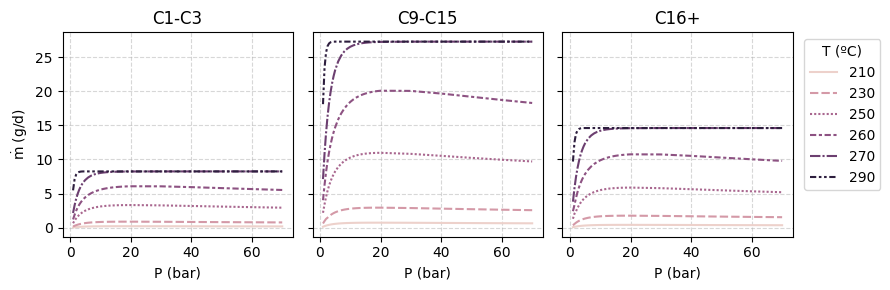

In [94]:
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns (carbon fractions) to iterate over
fractions = ['C1-C3', 'C9-C15', 'C16+']

# Initialize subplots
fig, ax = plt.subplots(1, 3, figsize=(9, 3), sharey=True)

for i, col in enumerate(fractions):
    # Melt only the necessary columns for the current subplot
    data_melted = parametric_data_onlyP[['P (bar)', 'T (ºC)', col]].melt(
        id_vars=['P (bar)', 'T (ºC)']
    )
    
    # Plotting
    sns.lineplot(
        data=data_melted,
        x='P (bar)',
        y='value',
        hue='T (ºC)',
        style='T (ºC)',
        ax=ax[i],
        legend=(i == 2) # Show legend only on the last plot to save space
    )
    
    # Formatting each subplot
    ax[i].set_title(col)
    ax[i].grid(True, which='both', linestyle='--', alpha=0.5)
    ax[i].set_ylabel(r'$\mathrm{\dot{m}}$ (g/d)' if i == 0 else "")

# Adjust legend position on the last axis
ax[2].legend(bbox_to_anchor=(1.02, 1), title='T (ºC)', loc='upper left')

plt.tight_layout()

# Save logic
fig_name = 'parametric_study_P.pdf'
save_path = f'Z:\\uem\\Doutorado\\Papers\\SAF_kinetics\\figures\\{fig_name}'
plt.savefig(save_path, bbox_inches='tight')
plt.show()